In [1]:
import matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.signal import find_peaks
from matplotlib.collections import LineCollection
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import utils
import nist_codes

try:
    import nist_helper
    descriptor_tokens = [t.lower() for t in getattr(nist_helper, "NIST_DESCRIPTORS", [])]
except Exception:
    nist_helper = None
    descriptor_tokens = []

In [2]:
HE_SHEET = "he test.xlsx"

df = pd.read_excel(HE_SHEET)
df_filtered = df[(df['nm'] >= 400) & (df['nm'] <= 750)].copy()

df_filtered = df_filtered.sort_values(by='nm').reset_index(drop=True)

print("DataFrame loaded successfully. Here are the first 5 rows:")
print(df.head())

DataFrame loaded successfully. Here are the first 5 rows:
   Unnamed: 0  Grey Val         nm  Unnamed: 3    Unnamed: 4  Unnamed: 5  \
0        2178   247.148  589.03701         NaN  max grey val         NaN   
1        2179   246.463  587.91075         NaN       247.148         NaN   
2        2180   243.830  586.78449         NaN           NaN         NaN   
3        2181   241.833  585.65823         NaN  min grey val         NaN   
4        2177   240.733  590.16327         NaN        16.674         NaN   

   Unnamed: 6 Unnamed: 7  
0  3042.03129   -1.12626  
1         NaN        NaN  
2         NaN        NaN  
3         NaN        NaN  
4         NaN    he_3584  


In [11]:
min_int = df_filtered['Grey Val'].min()
max_int = df_filtered['Grey Val'].max()
int_range = max_int - min_int

rgb = utils.wavelength_to_rgb

y_title = 'Intensity'
x_title = 'Wavelength (nm)'
fig_size = (15,6)
prominence = 0.12
dyn_prom = prominence * int_range
min_bright = 0.1
min_alpha = 0.1
min_alpha_scatter = 0.2
base_marker_size = 5
max_marker_size_factor = 95
x_min = 400
x_max = 750
mode = 'dark'
reverse_x = True
show_grid = True

if int_range == 0:
    df_filtered['Normalized_int'] = 1.0
else:
    df_filtered['Normalized_int'] = (df_filtered['Grey Val'] - min_int) / int_range

alpha_factor = df_filtered['Normalized_int']    # only applicable for scatter rn

In [4]:
def axis_labels():
    ax = plt.gca()

    if mode == 'dark':
        fig_bg = 'black'
        text = 'white'
        plt.gcf().set_facecolor('black')
        if show_grid is True:
            plt.grid(show_grid, color='darkgrey', linestyle=':', linewidth=0.5)
    else:
        fig_bg = 'white'
        text = 'black'
        if show_grid is True:
            plt.grid(show_grid)
    
    if reverse_x is True:
        plt.xlim(x_max, x_min)
    else:
        plt.xlim(x_min, x_max)

    ax.set_facecolor(fig_bg)
    plt.xlabel(x_title, color=text)
    plt.ylabel(y_title, color=text)
    plt.xticks(color=text)
    plt.yticks(color=text)

In [12]:
def final_alpha(alpha_min, alpha_factor):
    final_alpha = alpha_min + (1 - alpha_min) * alpha_factor
    return final_alpha

In [8]:
def scatter_iteration():
    sizes = base_marker_size + (max_marker_size_factor * alpha_factor)
    alphas = final_alpha(min_alpha_scatter, alpha_factor)

    # Create RGBA tuples for each point
    rgba_colors = []
    for i in range(len(df_filtered)):
        wavelength = df_filtered.iloc[i]['nm']
        r, g, b = rgb(wavelength)
        a = alphas.iloc[i]
        rgba_colors.append((r, g, b, a))

    plt.scatter(
        x=df_filtered['nm'],
        y=df_filtered['Grey Val'],
        c=rgba_colors,
        s=sizes,
        edgecolors='none', # No edge colors for the markers
        label='Emission Data'
    )

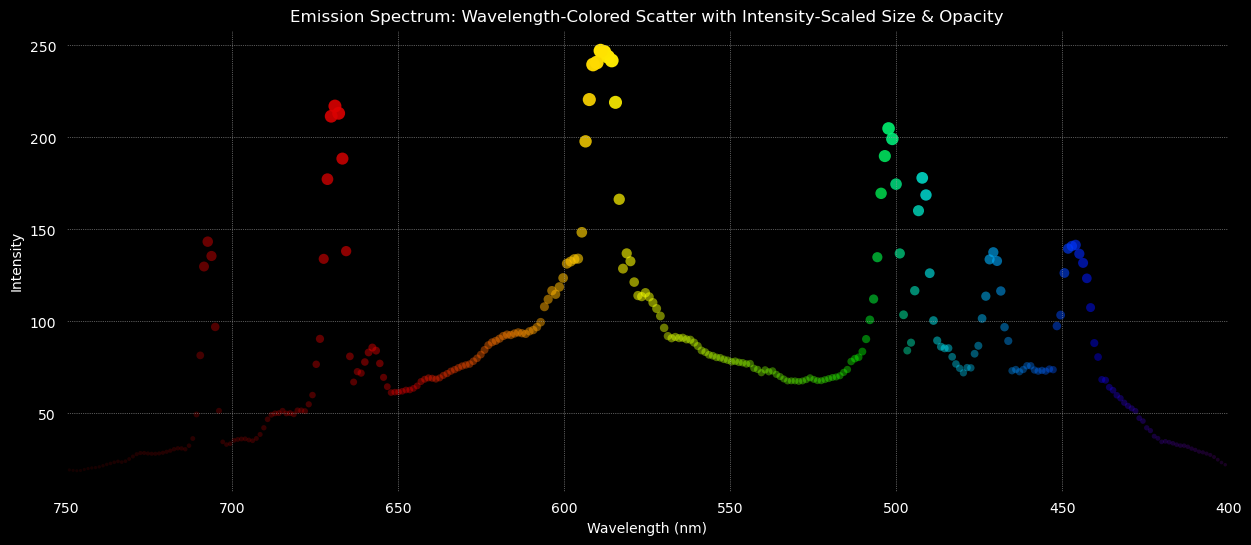

This visualization presents the emission spectrum as a scatter plot.
Each point is colored according to its wavelength, and its size and opacity (alpha) are scaled by its 'Grey Val' (intensity).
This creates a 'fuzzy' or 'sparkling' effect, distinct from continuous lines or filled areas, offering another perspective on the spectral data.


In [10]:
mode = 'dark'
plt.figure(figsize=fig_size)
axis_labels()

scatter_iteration()

plt.title('Emission Spectrum: Wavelength-Colored Scatter with Intensity-Scaled Size & Opacity', color='white')
plt.show()

print("This visualization presents the emission spectrum as a scatter plot.")
print("Each point is colored according to its wavelength, and its size and opacity (alpha) are scaled by its 'Grey Val' (intensity).")
print("This creates a 'fuzzy' or 'sparkling' effect, distinct from continuous lines or filled areas, offering another perspective on the spectral data.")